<a href="https://colab.research.google.com/github/soorya1723/Wine-Classification/blob/main/Wine_Quality_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fetching the csv file and importing necessary modules**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing all necessary modules that will be used to conduct our analysis.

*   **pandas** - To read the csv file and to create dataframes to get a better
understanding of results. We use the alias 'pd' to make it easy to call the module.

*   **seaborn** - To plot various graphs and visualize data. We use this module in order to understand correlations of various statistics of our wine quality data. We use the alias 'sns' to make it easy to call the module.

*   **matplotlib** - To create the plot objects where our seaborn graphs will be plotted. Specifically, we use the **pyplot** set of functions in order to create a *figure*, where the graph is to be plotted. We use the alias 'plt' to make it easy to call the module

*   **train_test_split** - We use this to split our data into train and test data. Specifically, it returns as trainX, trainY, testX, testY where X shows input and Y shows output.

*   **RandomForestClassifier** - We use the RandomForestClassifier() to create a model that classifies our wine data in terms of its statistics.

*   **classification_report** - To get general statistics such as precision and recall

*   **accuracy_score** - To get a general number that signifies how accurate our code is.












In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# **Preparing data for analysis**

In [ ]:
#Reading the csv file
wineData = pd.read_csv('/content/drive/MyDrive/winequality-red.csv')

#Checking various columns
print(wineData.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


# **Analysis of the wine quality data**

Checking first 5 rows and 5 rows in the middle to see get insight as to how the data looks. Additionally, this is also to check for any directly noticeable factors that create variation in wine quality.

In [ ]:
wineData[:50].head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
wineData[50:100].head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
50,8.8,0.66,0.26,1.7,0.074,4.0,23.0,0.9971,3.15,0.74,9.2,5
51,6.6,0.52,0.04,2.2,0.069,8.0,15.0,0.9956,3.40,0.63,9.4,6
52,6.6,0.50,0.04,2.1,0.068,6.0,14.0,0.9955,3.39,0.64,9.4,6
53,8.6,0.38,0.36,3.0,0.081,30.0,119.0,0.9970,3.20,0.56,9.4,5
54,7.6,0.51,0.15,2.8,0.110,33.0,73.0,0.9955,3.17,0.63,10.2,6


From seeing these values, we can see that volatile acidity, citric acid, chlorides density and sulphates are float values that lie between 0 and 1.

Getting the dimensions of our wineData array. It returns a tuple containing the number of rows and then the number of columns

In [ ]:
print(wineData.shape)

(1599, 12)


Checking if our inference of datatypes is correct

In [ ]:
wineData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


We can infer that all rows are non-null. Additionally, all columns except 'quality' are float datatypes.

**Correlations**

Checking how many wines of each quality are present.

<Axes: xlabel='quality', ylabel='count'>

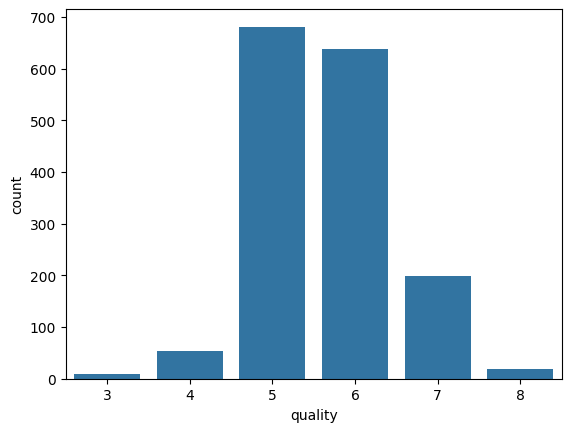

In [ ]:
sns.countplot(x='quality', data=wineData)

We can infer that most wines are of quality 5 or 6.

Trying to find relation between quality and volatile acidity

<Axes: xlabel='quality', ylabel='fixed acidity'>

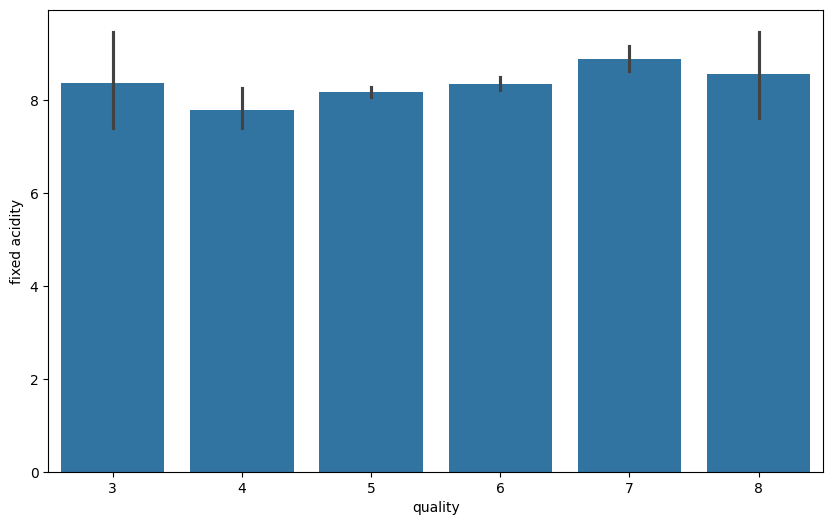

In [ ]:
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='quality', y='fixed acidity', data=wineData)

We can conclude that there's no clear correlation between the quality and fixed acidity. So let's check the other columns.

We could keep plotting bar graphs to find correlations but that makes our code lengthy.

 To keep it concise, we will be using the seaborn heatmap by getting a correlation set of data using the pandas corr() function. corr() returns a certain value and if its negative, it is inversely correlated. ie, the lower the value of one parameter the greater the value of the other and vice-versa in case of direct correlation.

The heatmap has multiple parameters we will be using:


1.   data : The correlation values. ie, the value by which a column is related to another

2.   annot : To give the correlation value that will correspond to the color given by the colorbar on the right

3.   cbar : To show the color bar on the right to show variation of color. We must set it to False if we do not want it.

4.   cmap : To specify a color palette to map colors based off the cbar. After specifying a certain color palette, if we end it with '_r', it reverses the color palette.

5.   fmt : To round off the value to a specific number of decimals. It accepts parameters in string format with the number of decimal places followed by an f.

6.   square : Set to True to make sure that each cell is a square.


<Axes: >

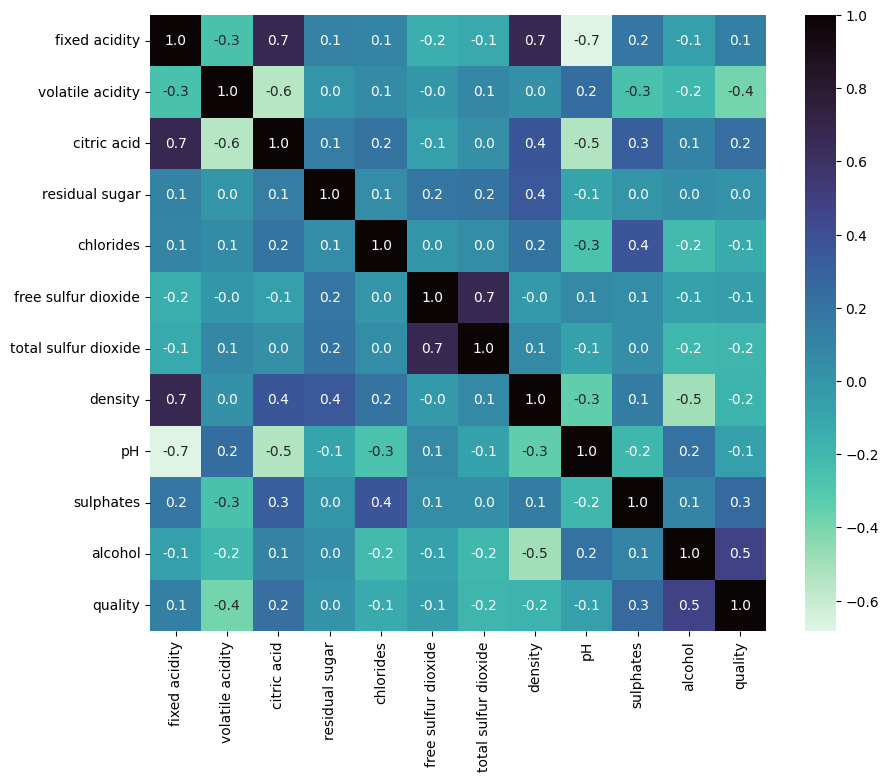

In [ ]:
wineCorrelation = wineData.corr()
f,ax = plt.subplots(figsize=(10,8))
sns.heatmap(wineCorrelation, annot=True, cbar=True, cmap='mako_r', fmt='.1f',square=True)

Data Preprocessing

Setting all independent parameters to a variable called indepParams and the dependent parameter, quality, to a variable called qual

In [ ]:
indepParams = wineData.drop('quality', axis=1)

print(indepParams, indepParams.shape)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

In [ ]:
qual = wineData['quality']

print(qual)

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64


Mapping quality values to strings, where quality < 6 is bad and quality > 6 is good.

In [ ]:
qual = qual.map({3 : 'bad', 4 :'bad', 5: 'bad',
                                   6: 'bad', 7: 'good', 8: 'good'})
print(qual)

0       bad
1       bad
2       bad
3       bad
4       bad
       ... 
1594    bad
1595    bad
1596    bad
1597    bad
1598    bad
Name: quality, Length: 1599, dtype: object


Checking how many good wines and bad wines are present in our dataset.

In [ ]:
qual.value_counts()

,count
quality,
bad,1382
good,217


# Splitting Data using train_test_split



Splitting variables into independent training and testing variables, as well as quality training and testing variables. The train_test_split function is used as follows:

i)takes arrays as input (which in our case is indepParams and qual)

ii)test_size is specified, which is a decimal value between 0 and 1, to partition how much of the data will be used for testing

iii)random_state, which is a number we set beforehand in order to ensure that we get the same results everytime.

In [ ]:
indepTrain, indepTest, qualTrain, qualTest = train_test_split(indepParams, qual, test_size=0.1, random_state=22)
print(indepTrain.shape)
print(qualTrain.shape)
print(indepTest.shape)
print(qualTest.shape)
print(qualTrain.values)

(1439, 11)
(1439,)
(160, 11)
(160,)
['bad' 'bad' 'bad' ... 'bad' 'bad' 'bad']


We create the model using the RandomForestClassifier() algorithm, which is an ensemble algorithm - an algorithm which uses multiple other algorithms in combination and finally takes the mean result of those.

 In our case, RandomForestClassifier() is an ensemble model made up of multiple Decision Trees. So, each decision tree gives a result and finally, it takes the mean of the results and gives a conclusion.

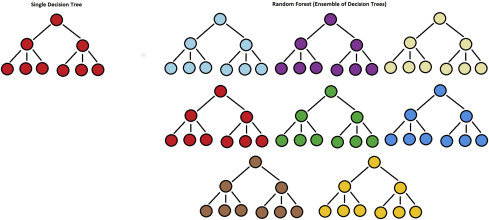

In [ ]:
model = RandomForestClassifier()
model.fit(indepTrain.values, qualTrain)

RandomForestClassifier()

Testing the model by giving it the 'independent test' parameters. Then, we coompare it with the actual quality of the particular cases and get a classification report with the general statistics of the data.

In [ ]:
trialTest = model.predict(indepTest.values)

classificationReport = classification_report(qualTest, trialTest)
print(classificationReport)
print(accuracy_score(qualTest, trialTest))

              precision    recall  f1-score   support

         bad       0.94      0.98      0.96       139
        good       0.81      0.62      0.70        21

    accuracy                           0.93       160
   macro avg       0.88      0.80      0.83       160
weighted avg       0.93      0.93      0.93       160

0.93125


Cell given to the user to test if their wine quality is good or bad.

In [ ]:
testList = [float(input('Enter fixed acidity: ')),
             float(input('Enter volatile acidity: ')),
             float(input('Enter citric acid: ')),
             float(input('Enter residual sugar: ')),
             float(input('Enter chlorides: ')),
             float(input('Enter free sulfur dioxide: ')),
             float(input('Enter total sulfur dioxide: ')),
             float(input('Enter density: ')),
             float(input('Enter pH: ')),
             float(input('Enter sulphates: ')),
             float(input('Enter alcohol: '))]
prediction = model.predict([testList])
print(f'\nWine Quality : {prediction[0]}')

Enter fixed acidity: 8.6
Enter volatile acidity: 0.52
Enter citric acid: 0.38
Enter residual sugar: 1.5
Enter chlorides: 0.096
Enter free sulfur dioxide: 5.0
Enter total sulfur dioxide: 18.0
Enter density: 0.996
Enter pH: 3.2
Enter sulphates: 0.52
Enter alcohol: 9.4

Wine Quality : bad
